In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import distance_transform_edt

In [ ]:
dirPath = './dataset/synthetic/64x64/' #example: dataset/synthetic/64x64/ 


mask_maps = np.load(dirPath + "mask.npy")
mask_map = mask_maps[0]
num_maps = mask_maps.shape[0]

FileNotFoundError: [Errno 2] No such file or directory: './dataset/synthetic/64x64/ mask.npy'

In [4]:
risk_maps = np.zeros_like(mask_maps, dtype=np.float32)
sigma = 8.0

for i in range(num_maps):
    dist_map = distance_transform_edt(mask_maps[i])

    risk_map = np.exp(-(dist_map ** 2)/(2 * sigma ** 2))
    risk_map = (risk_map - risk_map.min()) / (risk_map.max() - risk_map.min())

    risk_maps[i] = risk_map

np.save(dirPath + "risk_maps.npy", risk_maps)

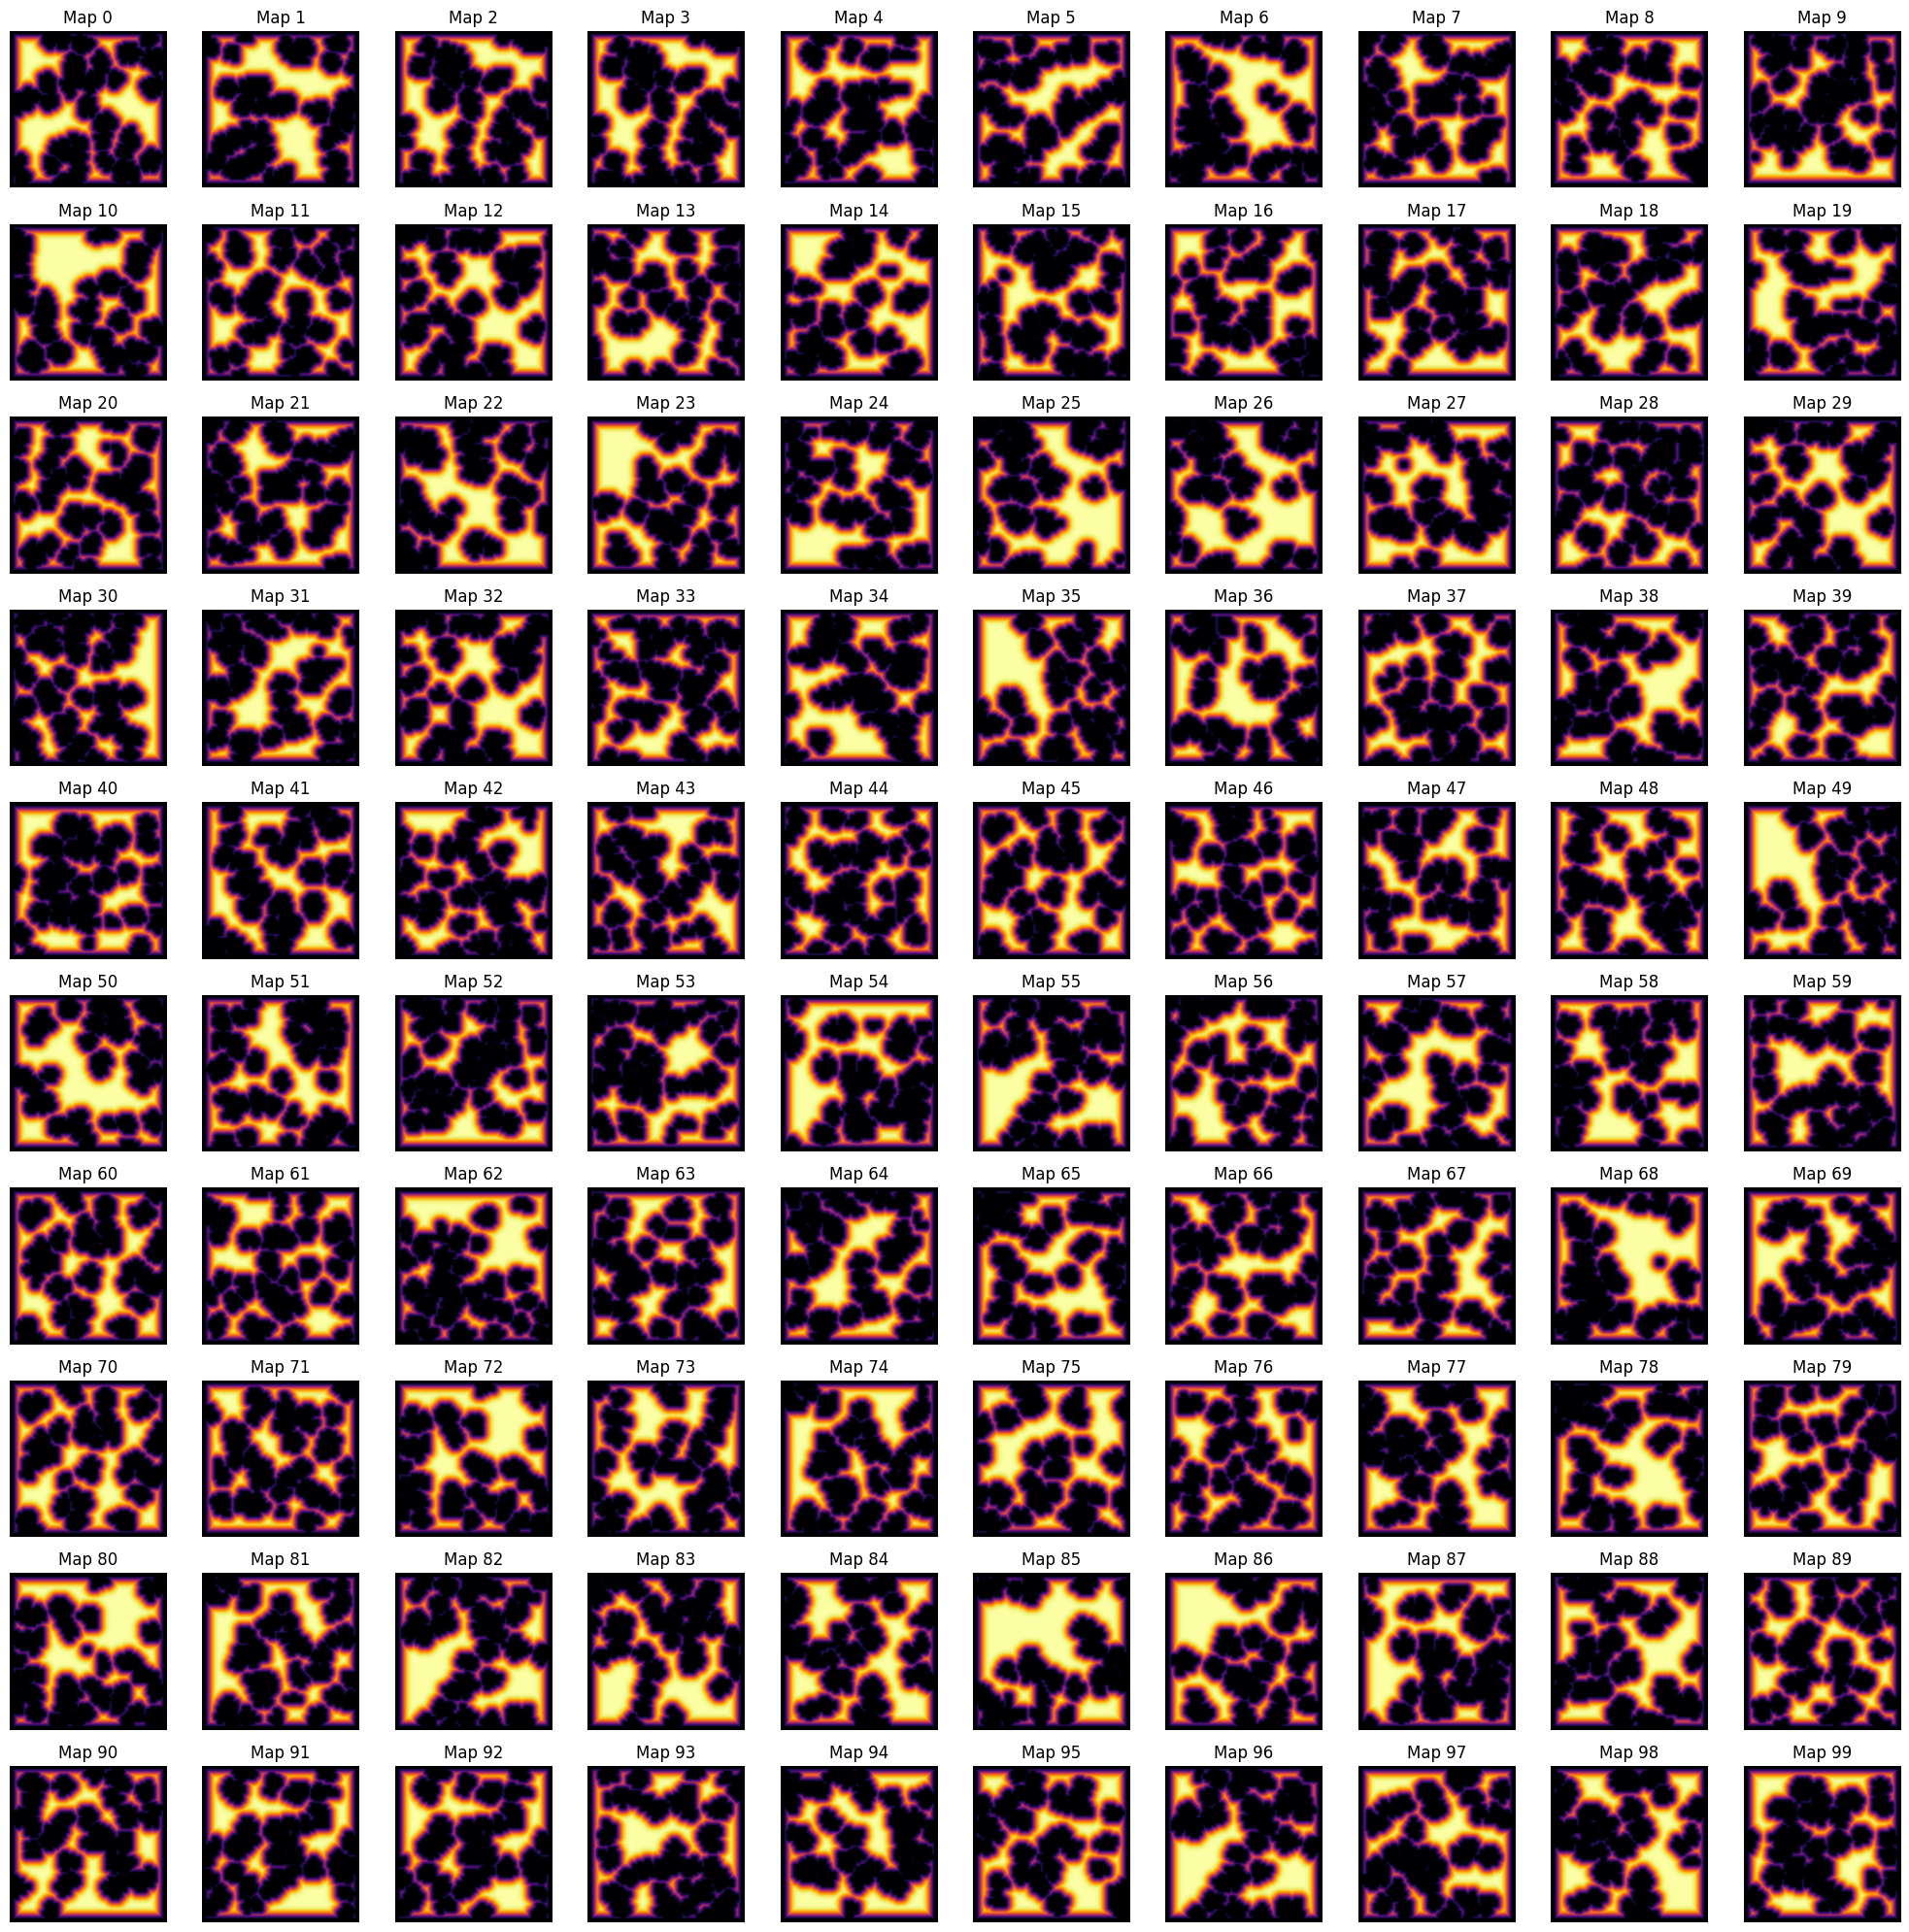

In [6]:
cols = 10
rows = (num_maps + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 2 * rows))
axes = axes.flatten()

for i in range(num_maps):
    ax = axes[i]
    ax.imshow(risk_maps[i], cmap='inferno_r', origin='lower')
    ax.set_title(f'Map {i}')
    ax.axis('off')

for i in range(num_maps, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
num_maps, H, W = risk_maps.shape
thresholds = np.arange(0.1, 1.01, 0.1)
layers = {}

for i in range(10):
    lower = i * 0.1
    upper = (i + 1) * 0.1

    layer = (risk_maps >= lower) & (risk_maps < upper)
    np.save(dirPath + f"risk_layer_{i}.npy", layer)

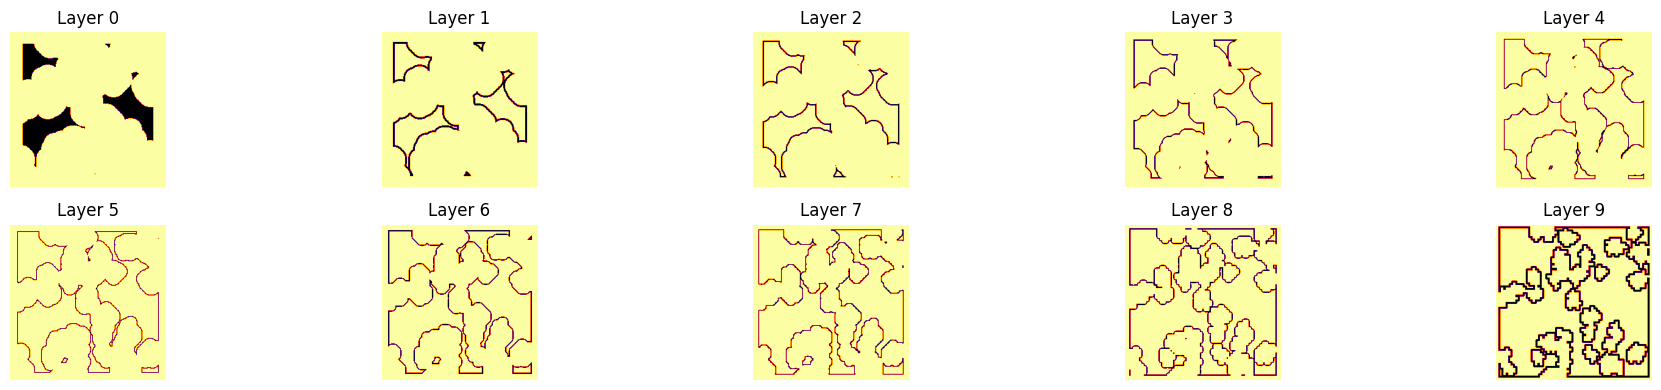

In [9]:
risk_layers = []
for i in range(10):
    risk_layers.append(np.load(dirPath + f"risk_layer_{i}.npy"))

cols = 5
rows = 2


fig, axes = plt.subplots(rows, cols, figsize=(20, 2 * rows))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    ax.imshow(risk_layers[i][0], cmap='inferno_r', origin='lower')
    ax.set_title(f'Layer {i}')
    ax.axis('off')

for i in range(10, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()